In [5]:
import pandas as pd 
import numpy as np
import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('./dataset/crop-recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


## **EDA**

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   object 
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency    2200 non-null   

In [8]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,20.151388,1.991364,8.570609,...,5.465652,3.515000,12.344959,49.850701,125.846403,1.999545,24.801013,2.003636,50.304701,2.990268
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,5.793720,0.812263,1.999382,...,2.605294,1.697912,4.297494,28.886354,43.564527,0.818999,14.523975,0.812021,28.580352,1.139637
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,10.024260,1.000000,5.000710,...,1.003338,1.000000,5.004341,0.038103,50.209990,1.000000,0.017756,1.000000,0.054911,1.002106
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,15.179949,1.000000,6.904620,...,3.203903,2.000000,8.585734,24.379866,88.030737,1.000000,12.212594,1.000000,26.104674,2.051814
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,20.088481,2.000000,8.609968,...,5.418049,4.000000,12.303616,49.982421,126.441536,2.000000,24.922548,2.000000,50.171934,2.968675
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,25.255146,3.000000,10.220394,...,7.686417,5.000000,15.975567,74.681904,163.850536,3.000000,37.322761,3.000000,75.262676,3.968736
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,29.997860,3.000000,11.991041,...,9.999990,6.000000,19.988474,99.983849,199.982166,3.000000,49.992046,3.000000,99.957274,4.997130


In [9]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
numeric_columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency'],
      dtype='object')

In [10]:
categoric_columns = data.select_dtypes(include=['object']).columns
categoric_columns

Index(['label'], dtype='object')

In [11]:
data['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

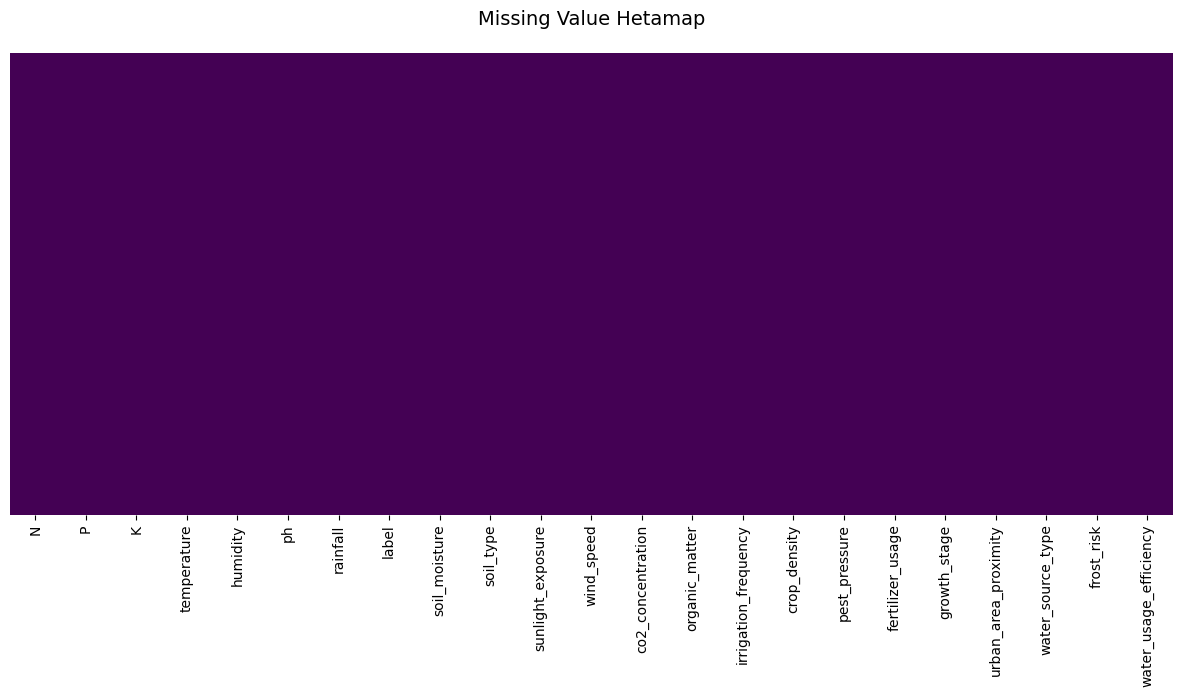


Jumlah Missing Value per Kolom:
N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
label                     0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
dtype: int64


In [12]:
plt.figure(figsize=(15,6))

sns.heatmap(
    data.isnull(),
    cmap='viridis',
    cbar=False,
    yticklabels=False,
)

plt.title('Missing Value Hetamap', fontsize=14, pad=20)
plt.tight_layout
plt.show()

print("\nJumlah Missing Value per Kolom:")
print(data.isnull().sum())

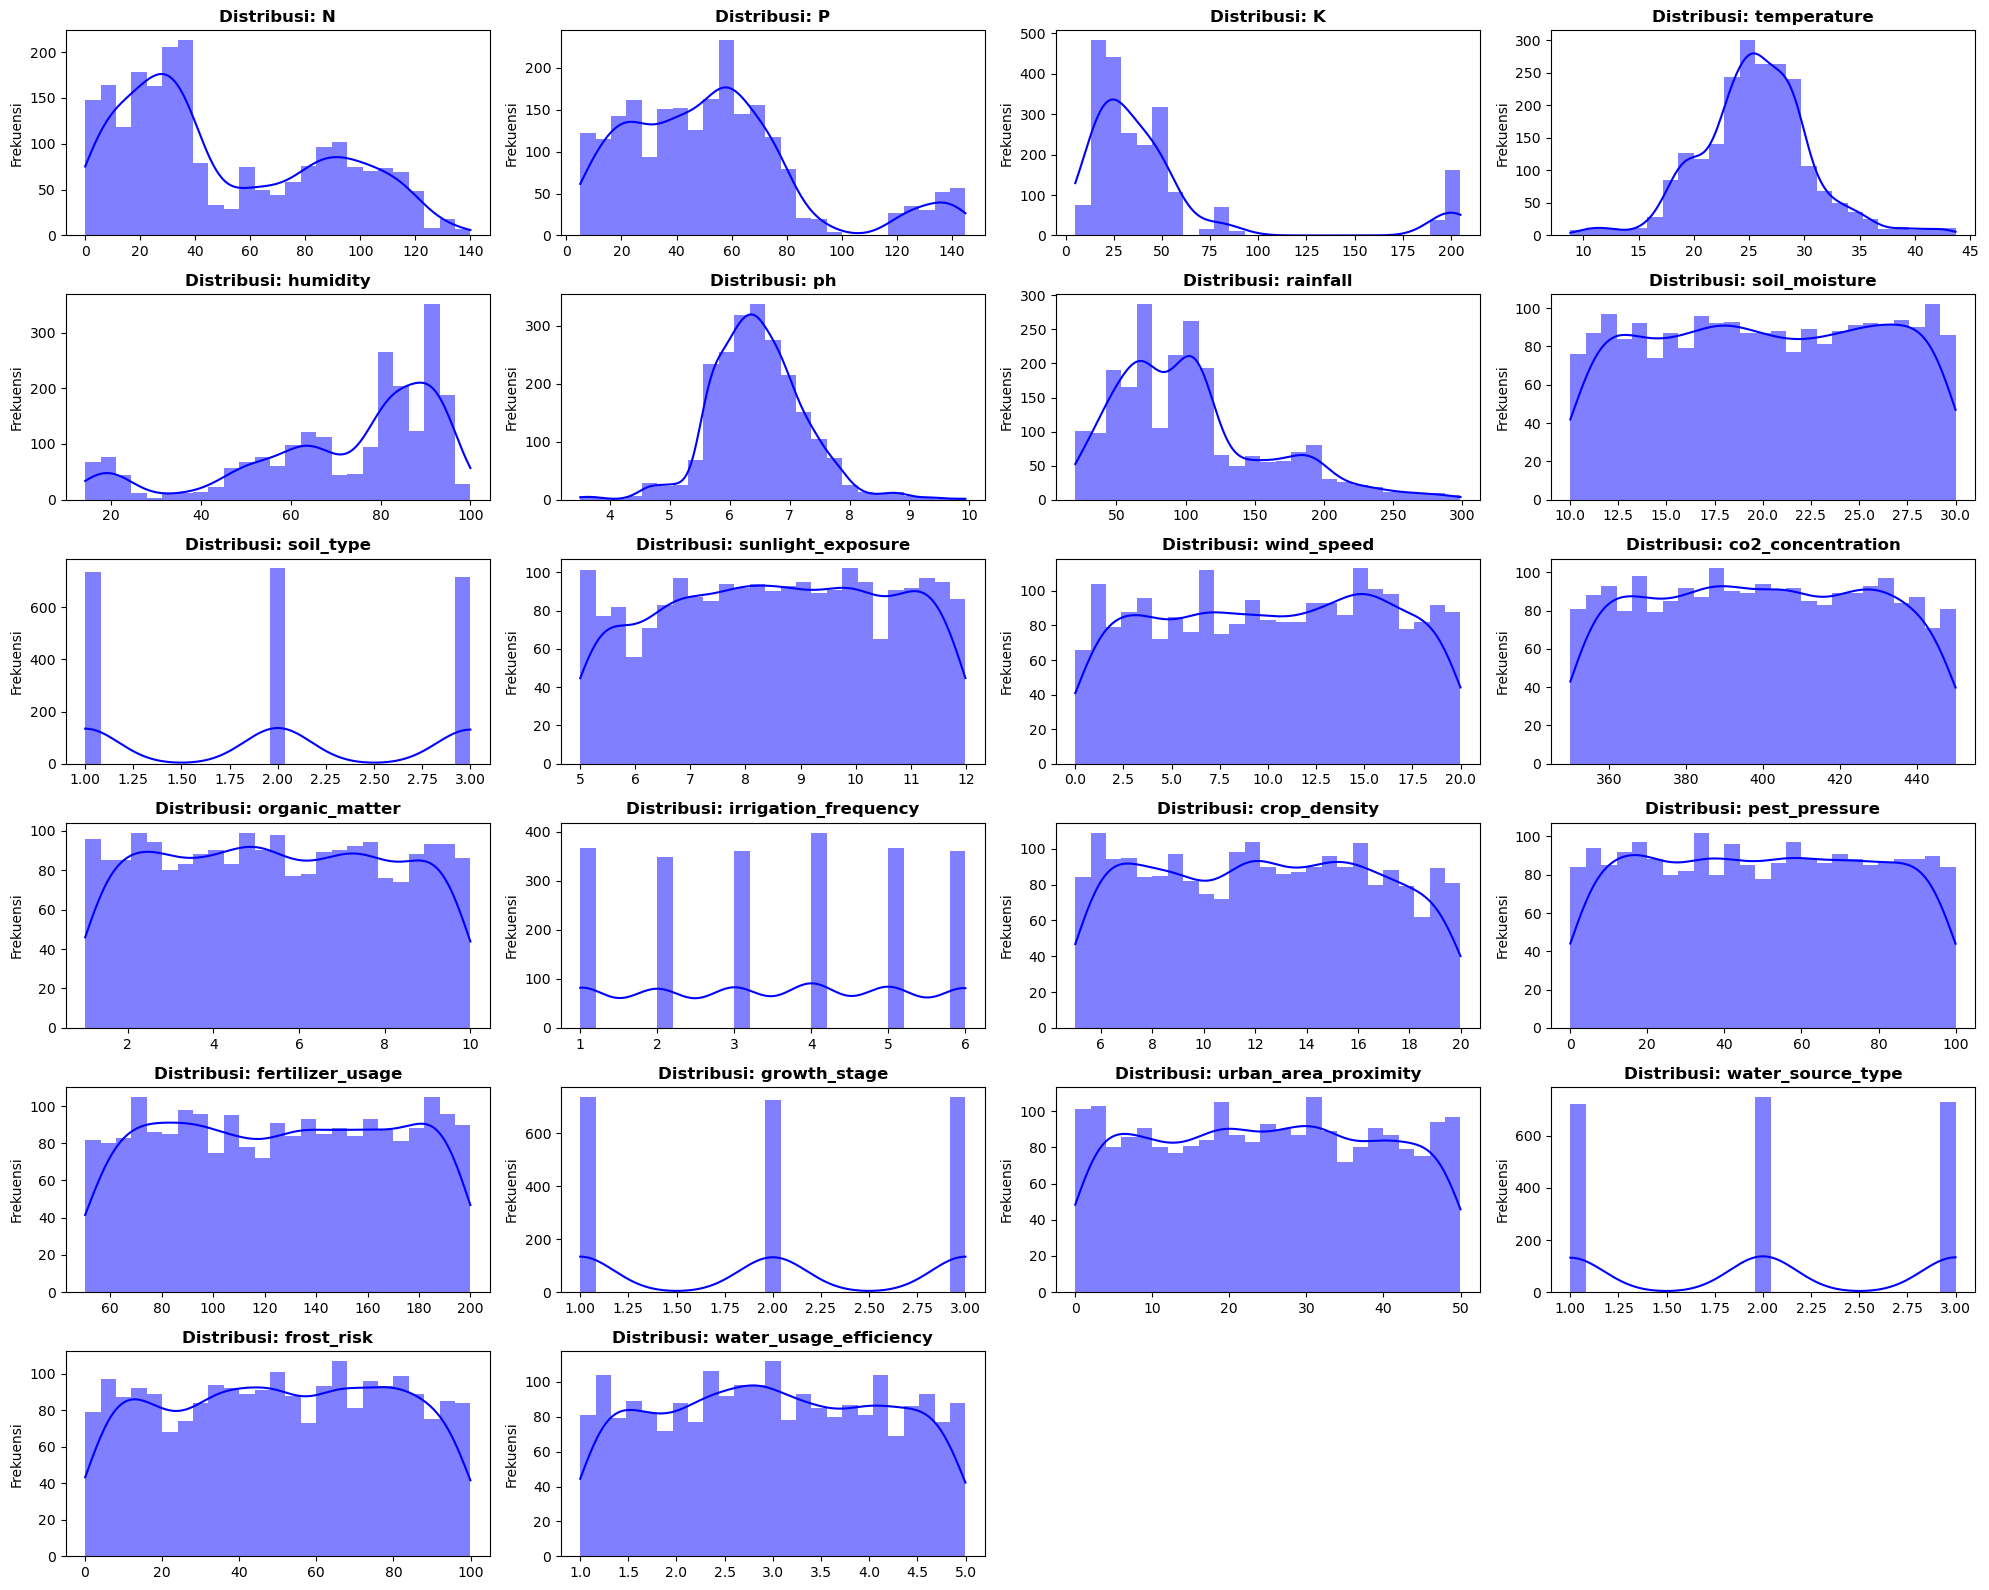

In [13]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 16))
axes = axes.flatten() 

for i, col in enumerate(numeric_columns):
    sns.histplot(data[col], kde=True, ax=axes[i], color='blue', edgecolor=None, bins=25)
    axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

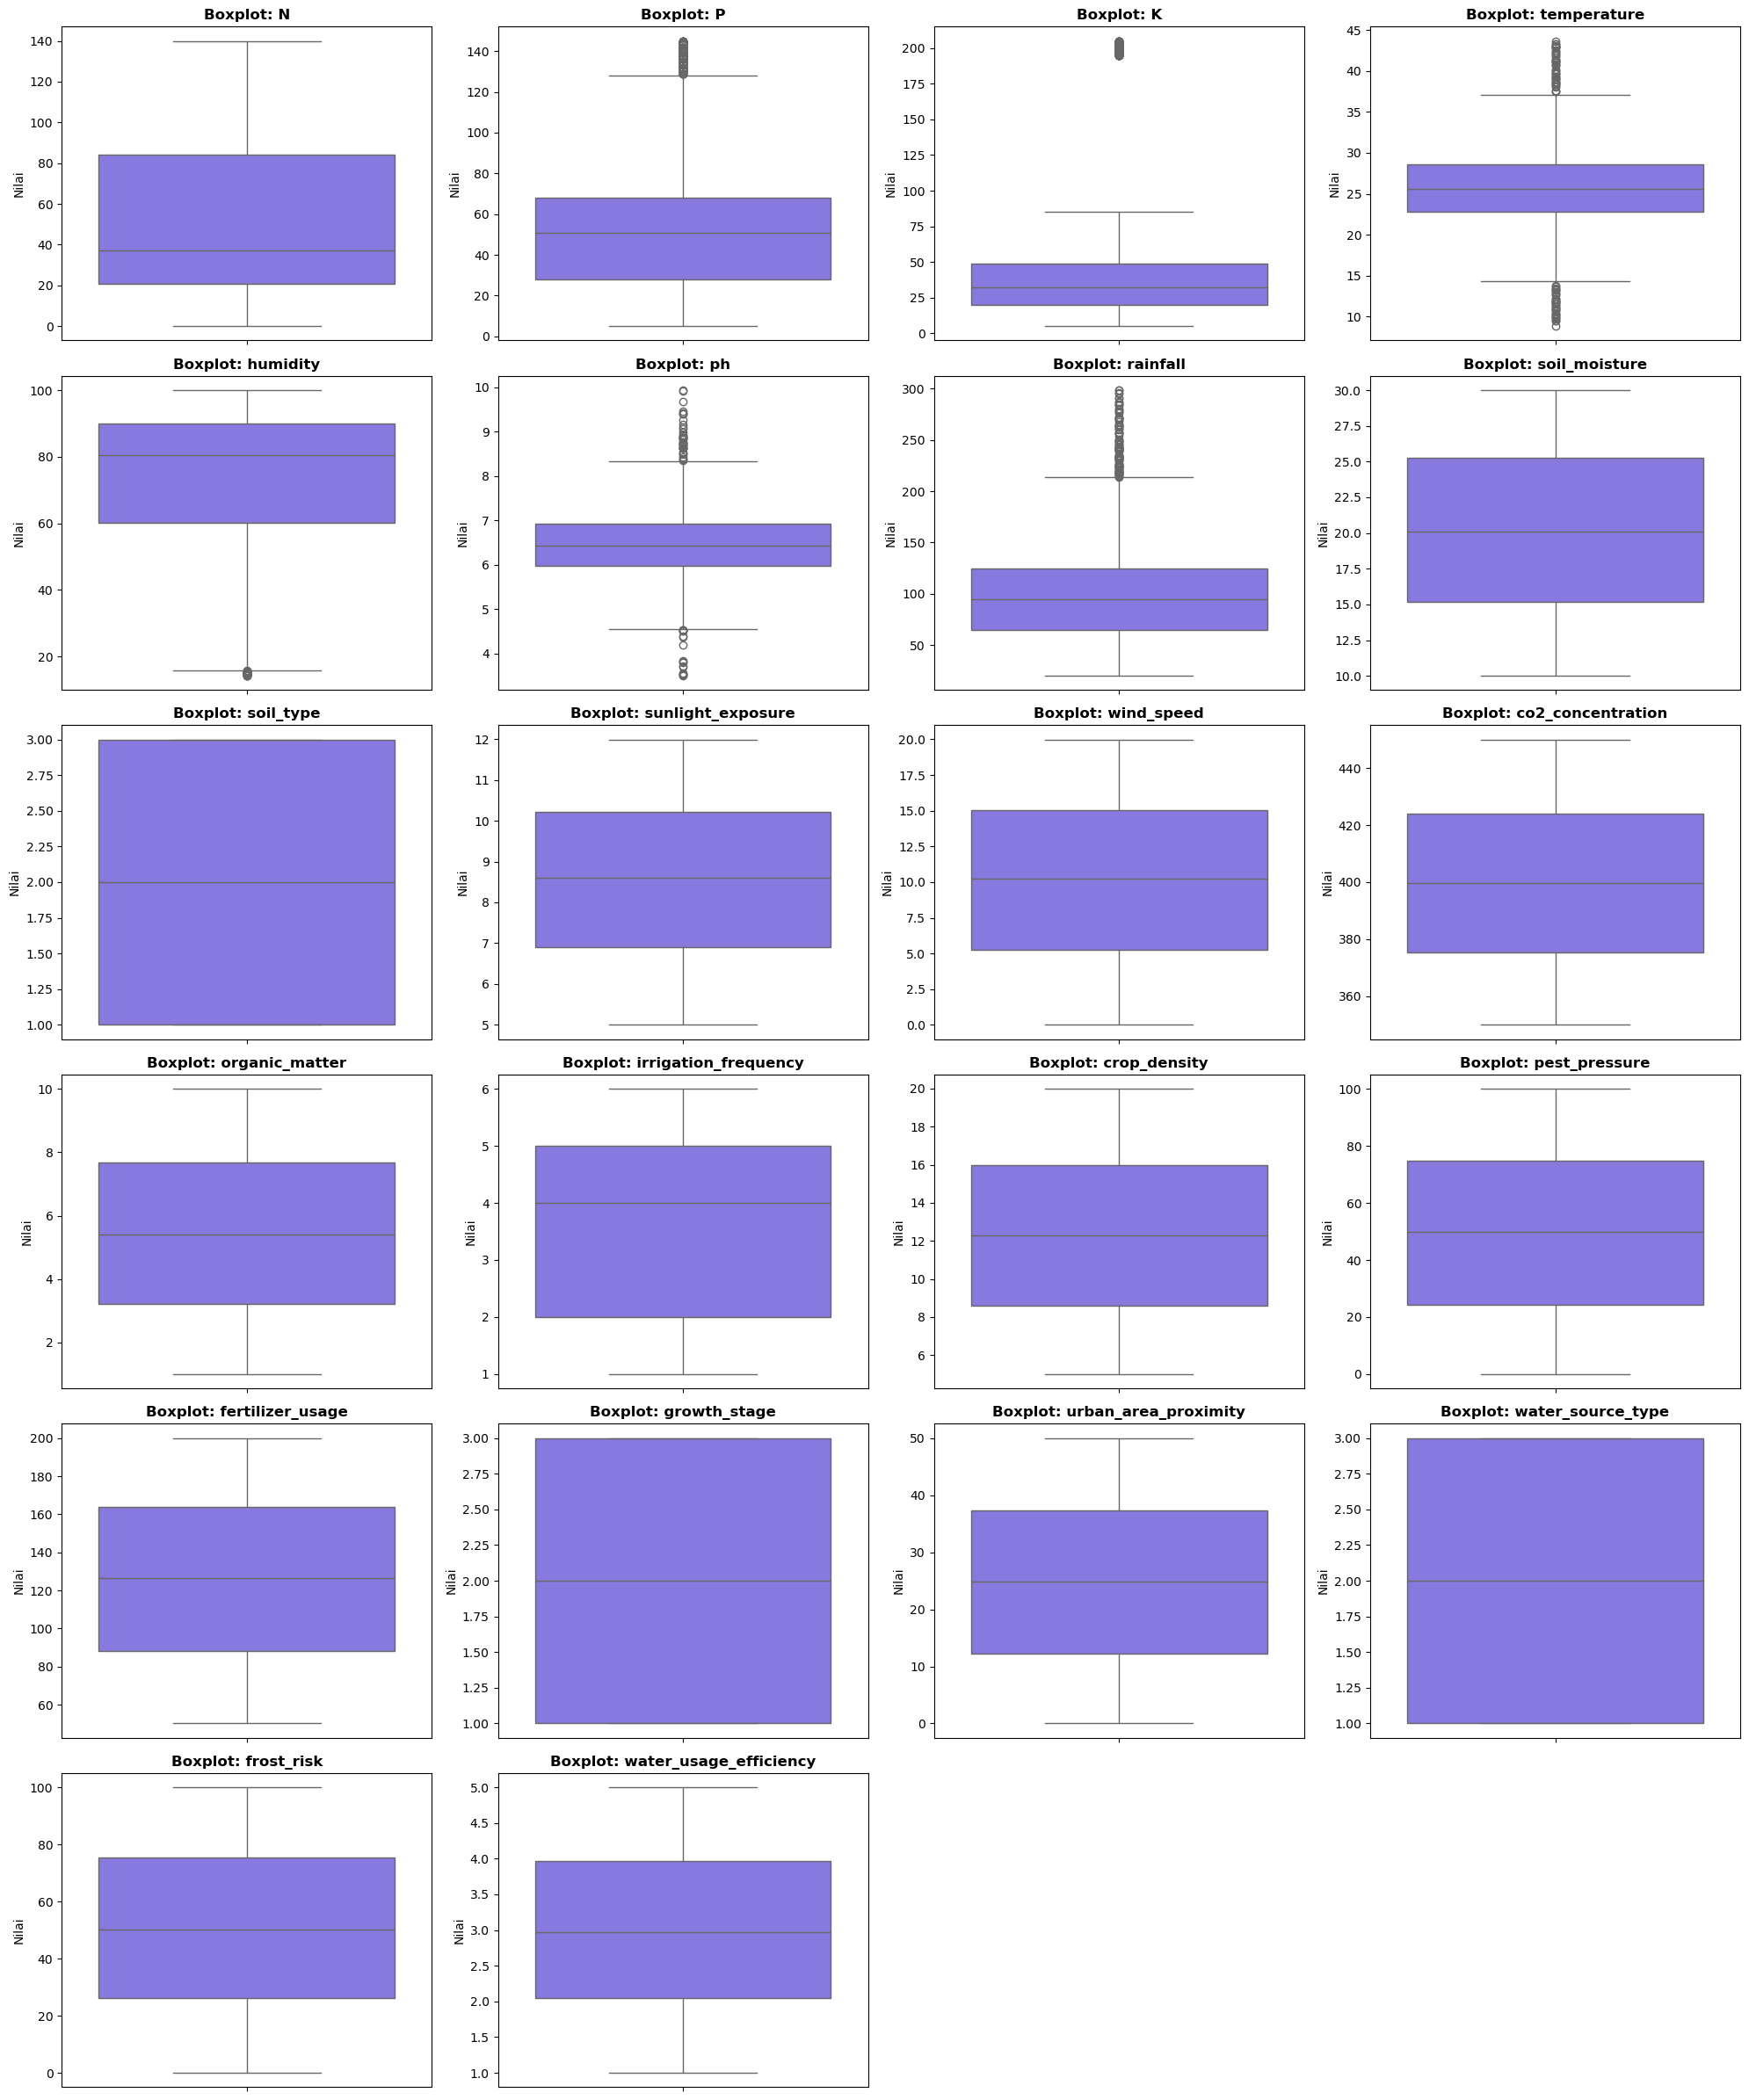

In [14]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=data[col], ax=axes[i], color='mediumslateblue')
    axes[i].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


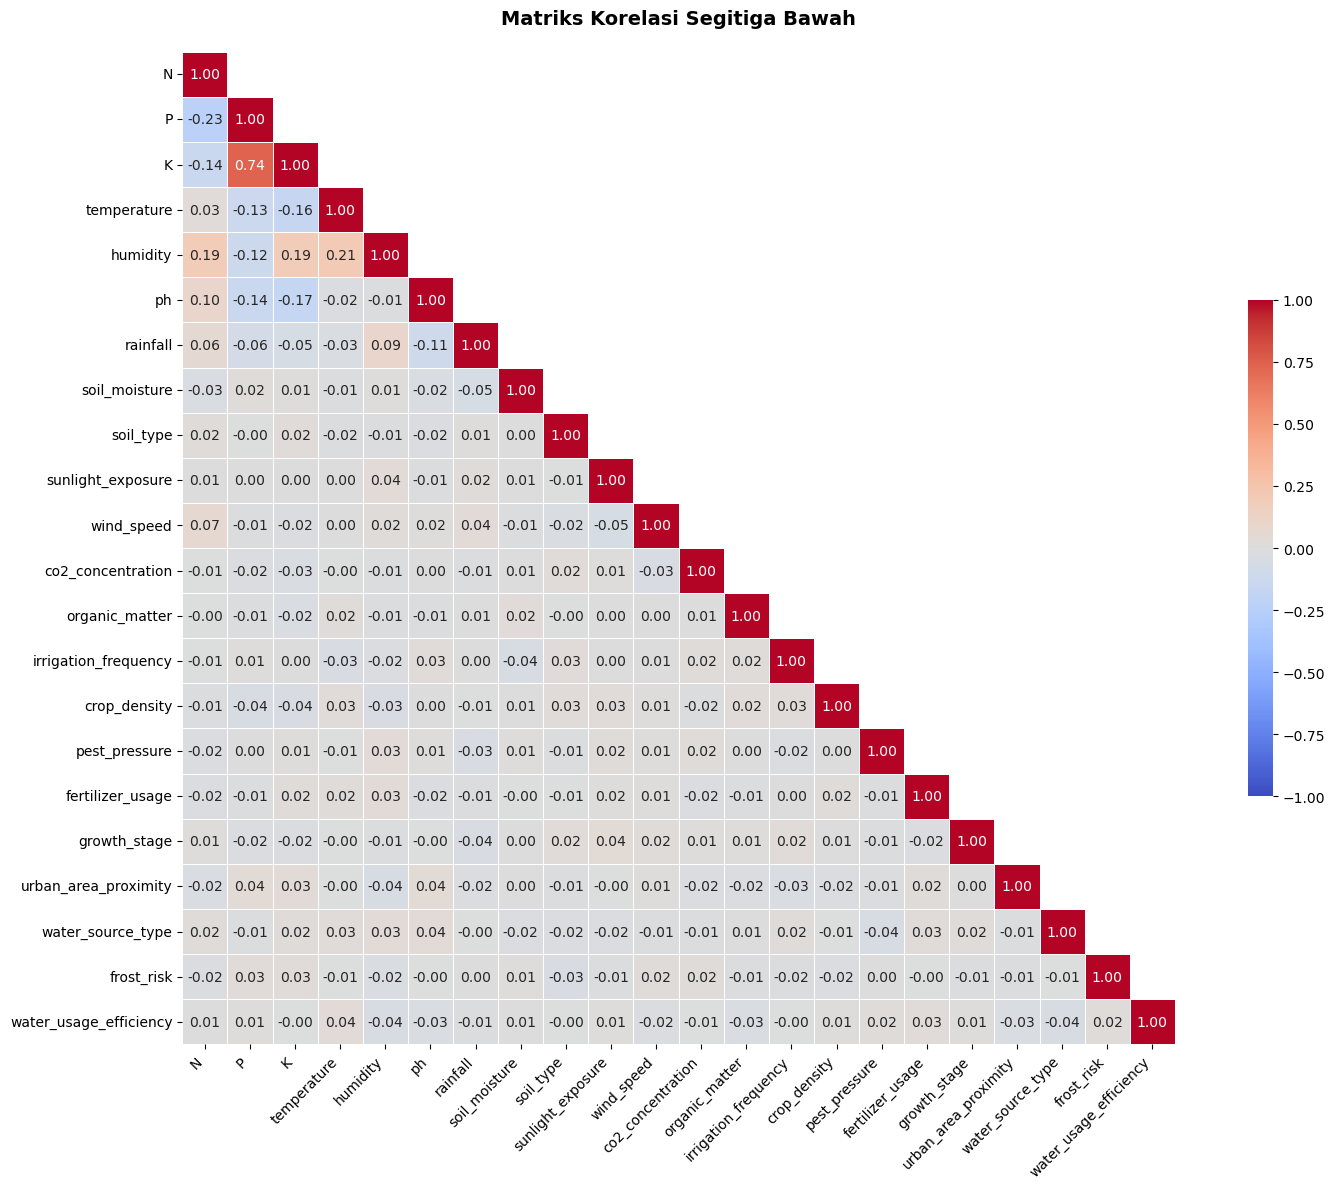

In [15]:
correlation = data[numeric_columns].corr()

mask = np.triu(np.ones_like(correlation, dtype=bool,), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation, 
            mask=mask,               
            annot=True,             
            fmt=".2f",               
            cmap='coolwarm',         
            vmax=1, vmin=-1,         
            center=0,                
            square=True,             
            linewidths=.5,           
            cbar_kws={"shrink": .5})


plt.title('Matriks Korelasi Segitiga Bawah', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


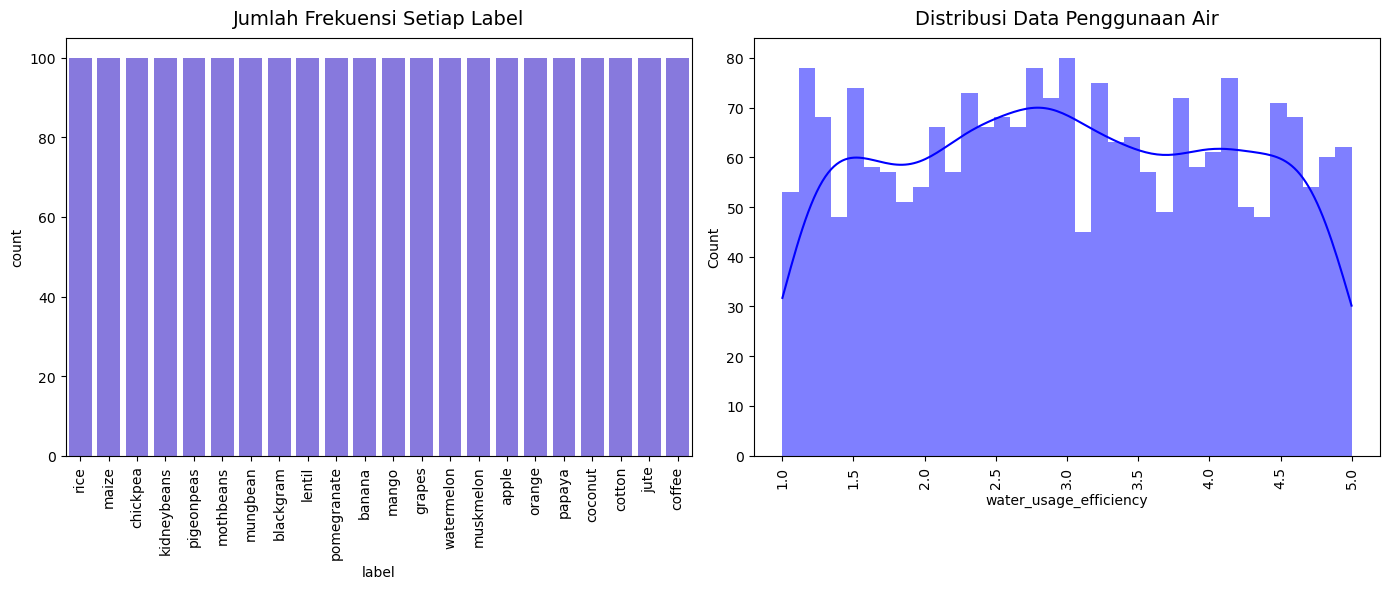

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=data, x='label', color='mediumslateblue', ax=axes[0])
axes[0].set_title("Jumlah Frekuensi Setiap Label", fontsize=14, pad=10)
axes[0].tick_params(axis='x', rotation=90)

sns.histplot(data=data, x='water_usage_efficiency', color='blue', ax=axes[1], kde=True, bins=35, edgecolor=None)
axes[1].set_title("Distribusi Data Penggunaan Air", fontsize=14, pad=10)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

/var/folders/_k/f1z5qn1j69ndqz077_sqtcb40000gn/T/ipykernel_13837/3842254001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='rainfall', palette='viridis')


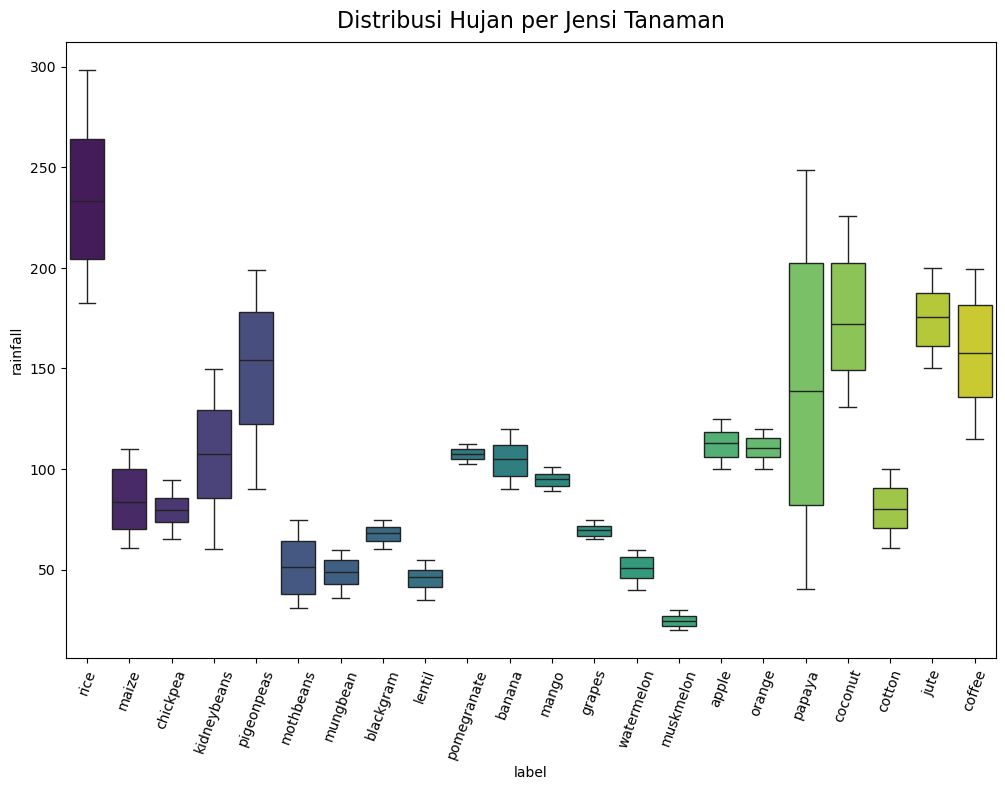

In [17]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=data, x='label', y='rainfall', palette='viridis')
plt.title("Distribusi Hujan per Jensi Tanaman", fontsize=16, pad=10)
plt.tick_params(axis='x', rotation=70)
plt.tight_layout
plt.show()


/var/folders/_k/f1z5qn1j69ndqz077_sqtcb40000gn/T/ipykernel_13837/2252957167.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y=columns, ax=axes[i], palette='viridis')
/var/folders/_k/f1z5qn1j69ndqz077_sqtcb40000gn/T/ipykernel_13837/2252957167.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y=columns, ax=axes[i], palette='viridis')
/var/folders/_k/f1z5qn1j69ndqz077_sqtcb40000gn/T/ipykernel_13837/2252957167.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y=columns, ax

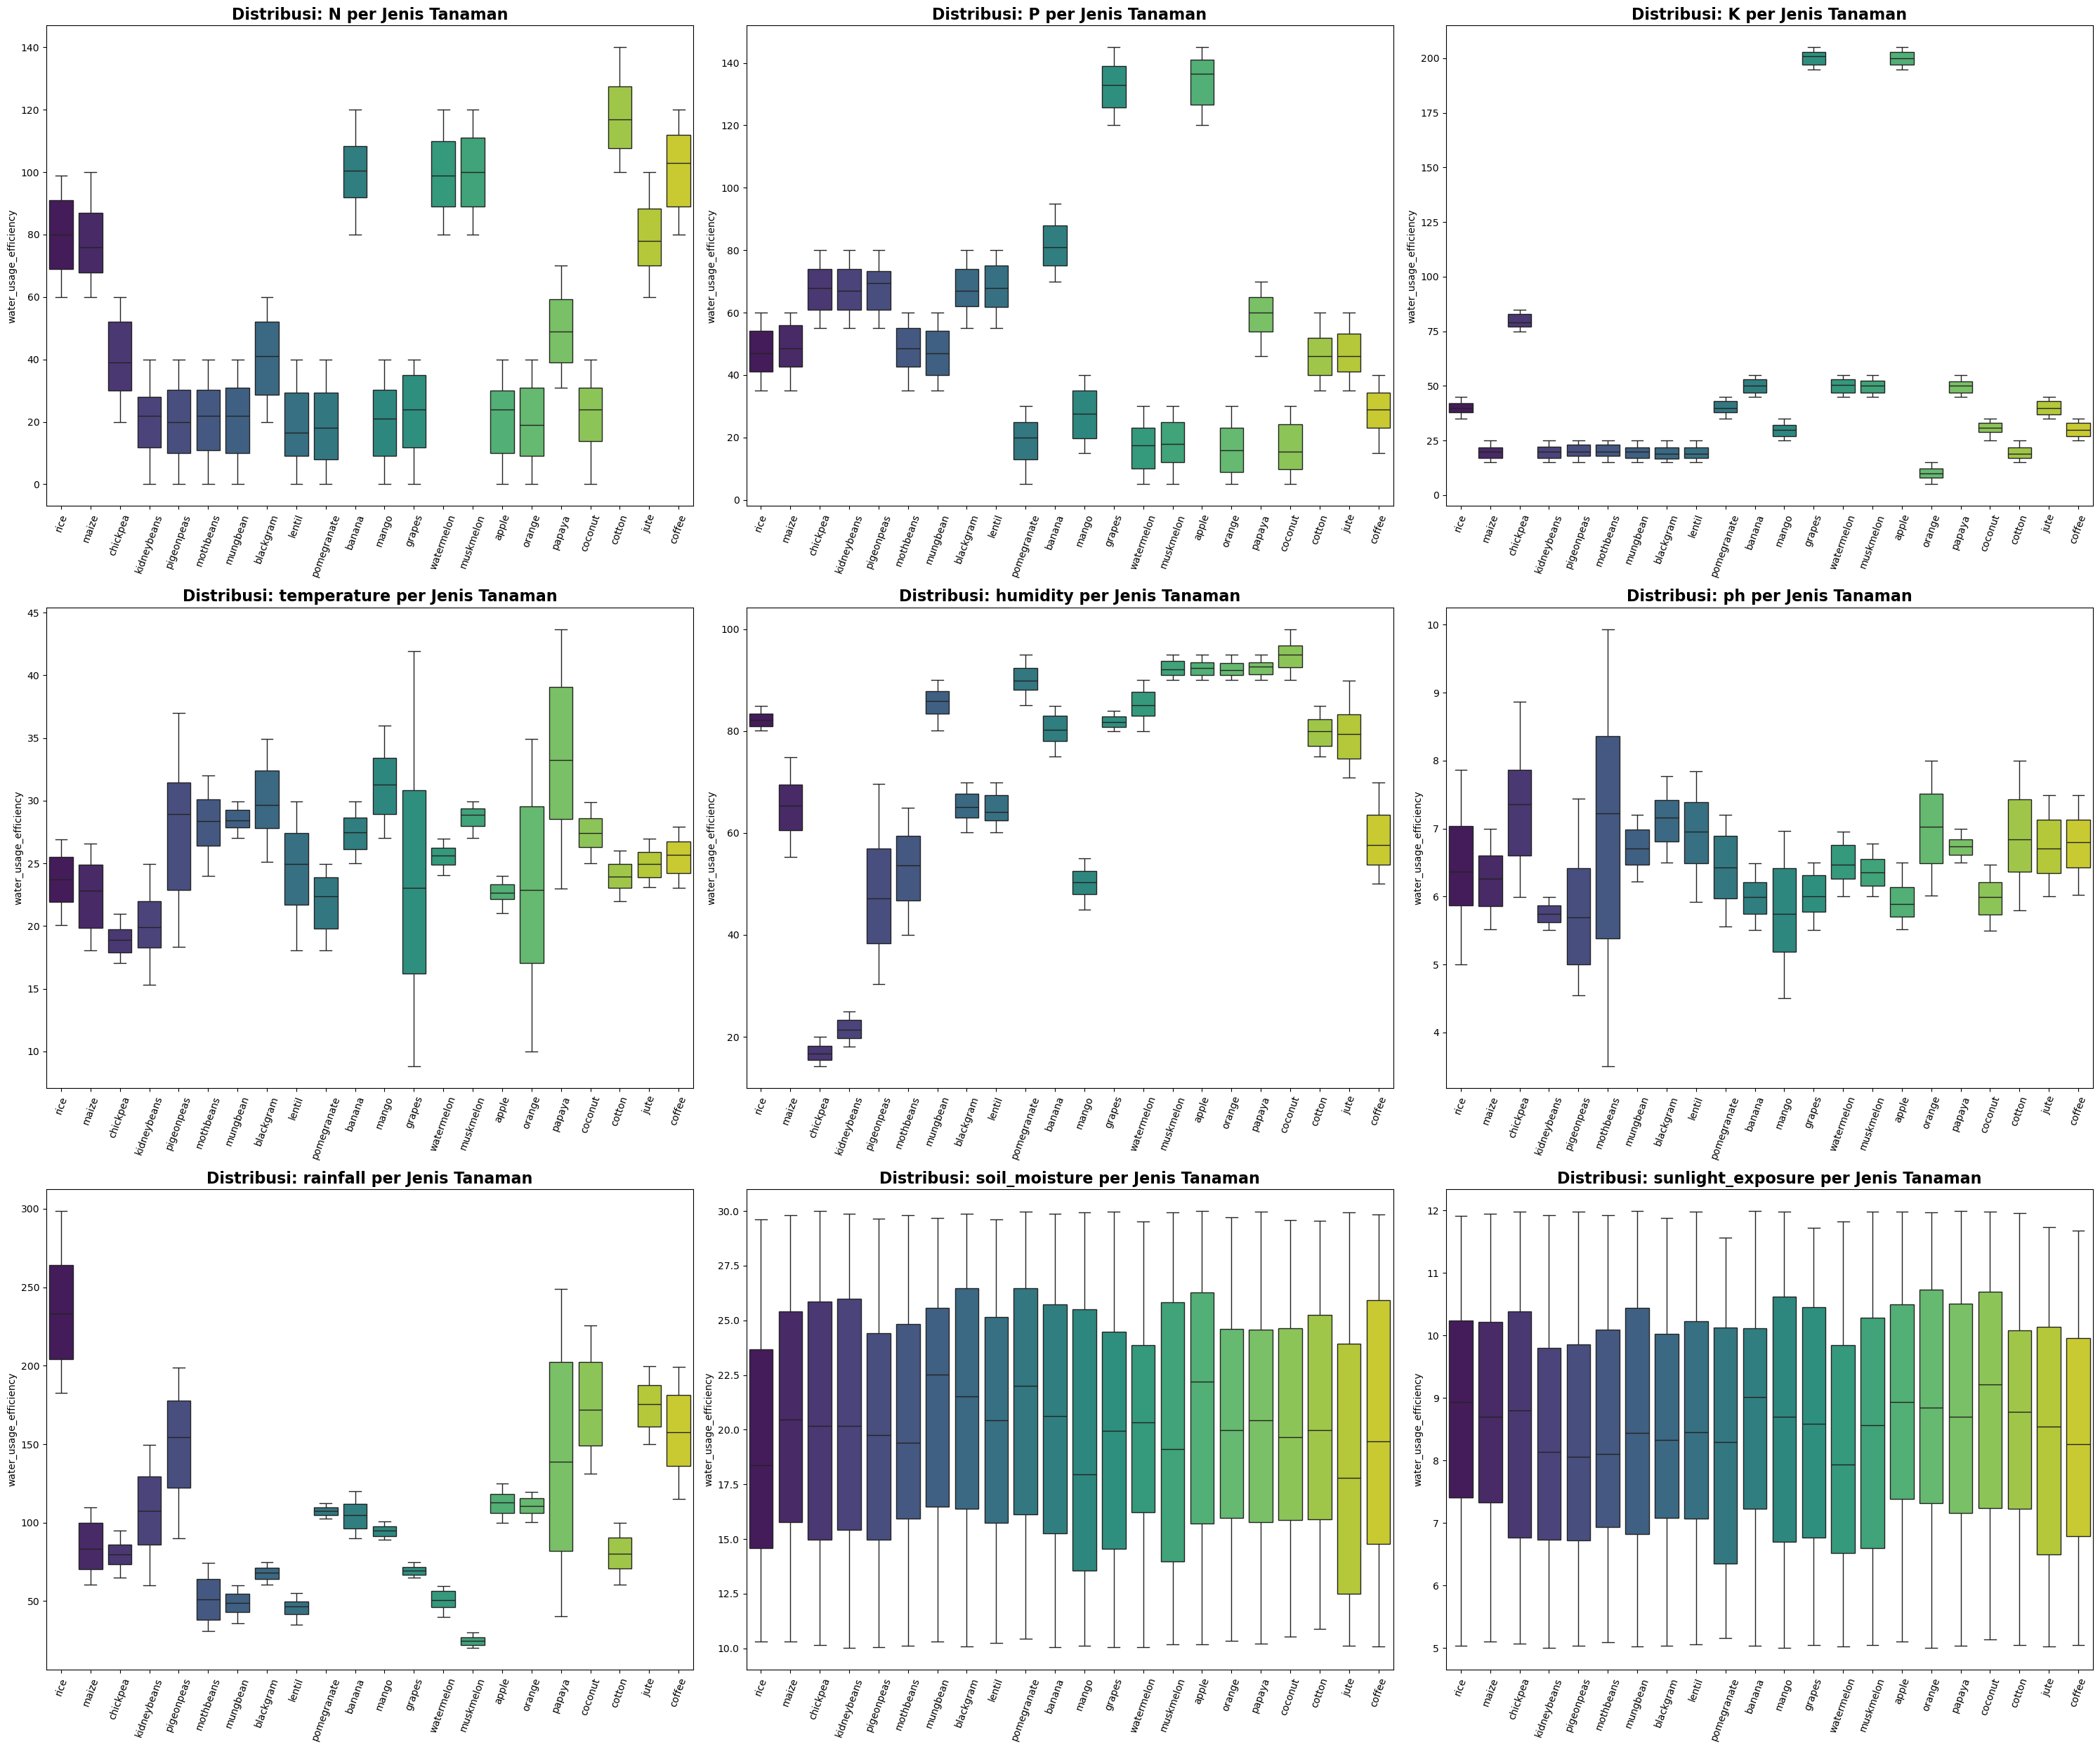

In [18]:
fitur_dasar = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_moisture', 'sunlight_exposure']

fig, axes = plt.subplots(3,3, figsize=(30, 25))
axes = axes.flatten()

for i, columns in enumerate(fitur_dasar):
    sns.boxplot(data=data, x='label', y=columns, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribusi: {columns} per Jenis Tanaman', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('') 
    axes[i].set_ylabel(col)

    axes[i].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()
